In [1]:
import pandas as pd
import numpy as np

In [2]:
forecast = pd.read_csv("../data/processed/sales_daily.csv")

inventory = pd.read_csv("../data/processed/inventory_snapshots.csv")

In [3]:
forecast_summary = (
    forecast.groupby("StockCode")
            .agg(
                Forecast_Demand=("units_sold","mean")
            )
            .reset_index()
)

In [4]:
risk = forecast_summary.merge(
    inventory,
    on="StockCode"
)

In [5]:
risk["Available_Stock"] = (

    risk["on_hand_units"]

    +

    risk["on_order_units"]

)

In [6]:
risk["Stockout_Risk"] = np.where(

    risk["Available_Stock"]

    <

    risk["Forecast_Demand"]

    *

    risk["lead_time_days"],

    "High",

    "Low"

)

In [7]:
risk["Overstock_Risk"] = np.where(

    risk["Available_Stock"]

    >

    risk["Forecast_Demand"]

    *30,

    "High",

    "Low"

)

In [8]:
def recommendation(row):

    if row["Stockout_Risk"]=="High":

        return "Reorder Now"

    elif row["Overstock_Risk"]=="High":

        return "Markdown"

    else:

        return "Healthy"

risk["Recommendation"]=risk.apply(

    recommendation,

    axis=1

)

In [9]:
risk.head()

,StockCode,Forecast_Demand,avg_daily_sales,on_hand_units,on_order_units,lead_time_days,reorder_point,Available_Stock,Stockout_Risk,Overstock_Risk,Recommendation
0,10002,38.537778,38.537778,616,18,17,655,634,High,Low,Reorder Now
1,10002R,1.333333,1.333333,38,86,14,18,124,Low,High,Markdown
2,10080,12.115385,12.115385,290,33,7,84,323,Low,Low,Healthy
3,10109,4.000000,4.000000,80,12,7,28,92,Low,Low,Healthy
4,10120,10.375000,10.375000,176,42,5,51,218,Low,Low,Healthy


In [10]:
risk.to_csv(

    "../data/processed/risk_scores.csv",

    index=False

)

print("Risk Scoring Completed!")

Risk Scoring Completed!


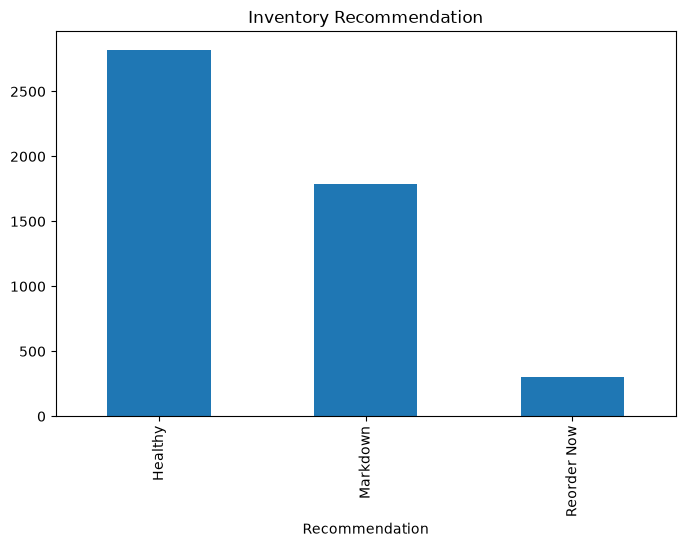

In [11]:
import matplotlib.pyplot as plt

risk["Recommendation"].value_counts().plot(

    kind="bar",

    figsize=(8,5)

)

plt.title("Inventory Recommendation")

plt.show()

In [12]:
import pandas as pd
import numpy as np
import joblib

In [13]:
inventory = pd.read_csv(
    "../data/processed/inventory_snapshots.csv"
)

features = pd.read_csv(
    "../data/processed/daily_sales_features.csv",
    parse_dates=["Date"]
)

C:\Users\vicky\AppData\Local\Temp\ipykernel_24368\3981752865.py:5: DtypeWarning: Columns (0: StockCode) have mixed types. Specify dtype option on import or set low_memory=False.
  features = pd.read_csv(


In [14]:
model = joblib.load(
    "../models/random_forest_forecast.pkl"
)

In [15]:
latest = (
    features
    .sort_values("Date")
    .groupby("StockCode")
    .tail(1)
)

latest.head()

,Date,StockCode,Units_Sold,Revenue,Year,Month,Week,Day,DayOfWeek,Lag_1,Lag_7,Rolling_7
33998,2009-12-13,20940,2,5.90,2009,12,50,13,6,18.0,3.0,10.142857
403977,2009-12-16,48179,2,27.74,2009,12,51,16,2,22.0,1.0,4.428571
431472,2009-12-18,84247J,1,0.86,2009,12,51,18,4,2.0,1.0,1.285714
105438,2009-12-21,21543,1,0.85,2009,12,52,21,0,2.0,11.0,5.857143
95490,2009-12-22,21480,2,12.08,2009,12,52,22,1,1.0,2.0,15.571429


In [16]:
X = latest[
    [
        "Year",
        "Month",
        "Week",
        "Day",
        "DayOfWeek",
        "Lag_1",
        "Lag_7",
        "Rolling_7"
    ]
]

latest["Forecast_Demand"] = model.predict(X)

latest.head()

,Date,StockCode,Units_Sold,Revenue,Year,Month,Week,Day,DayOfWeek,Lag_1,Lag_7,Rolling_7,Forecast_Demand
33998,2009-12-13,20940,2,5.90,2009,12,50,13,6,18.0,3.0,10.142857,5.103333
403977,2009-12-16,48179,2,27.74,2009,12,51,16,2,22.0,1.0,4.428571,1.800000
431472,2009-12-18,84247J,1,0.86,2009,12,51,18,4,2.0,1.0,1.285714,1.258500
105438,2009-12-21,21543,1,0.85,2009,12,52,21,0,2.0,11.0,5.857143,2.830000
95490,2009-12-22,21480,2,12.08,2009,12,52,22,1,1.0,2.0,15.571429,2.503333


In [17]:
risk = latest.merge(
    inventory,
    on="StockCode"
)

In [18]:
risk["Available_Stock"] = (

    risk["on_hand_units"]

    +

    risk["on_order_units"]

)

In [19]:
risk["Stockout_Risk"] = np.where(

    risk["Available_Stock"]

    <

    risk["Forecast_Demand"]

    *

    risk["lead_time_days"],

    "High",

    "Low"

)

In [20]:
risk["Overstock_Risk"] = np.where(

    risk["Available_Stock"]

    >

    risk["Forecast_Demand"]

    *30,

    "High",

    "Low"

)

In [21]:
def recommend(row):

    if row["Stockout_Risk"] == "High":

        return "Reorder"

    elif row["Overstock_Risk"] == "High":

        return "Markdown"

    else:

        return "Healthy"


risk["Recommendation"] = risk.apply(

    recommend,

    axis=1

)

In [22]:
risk.to_csv(

    "../data/processed/risk_scores.csv",

    index=False

)

print("Risk Score Created Successfully!")

Risk Score Created Successfully!


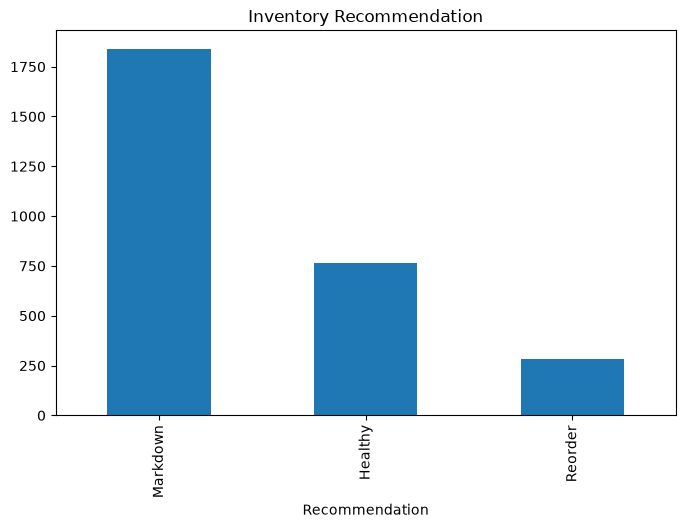

In [23]:
import matplotlib.pyplot as plt

risk["Recommendation"].value_counts().plot(

    kind="bar",

    figsize=(8,5)

)

plt.title("Inventory Recommendation")

plt.show()